In [189]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

### Detección del borde con envolvente convexa

¡Éxito! Se detectó el recuadro exterior del tablero.


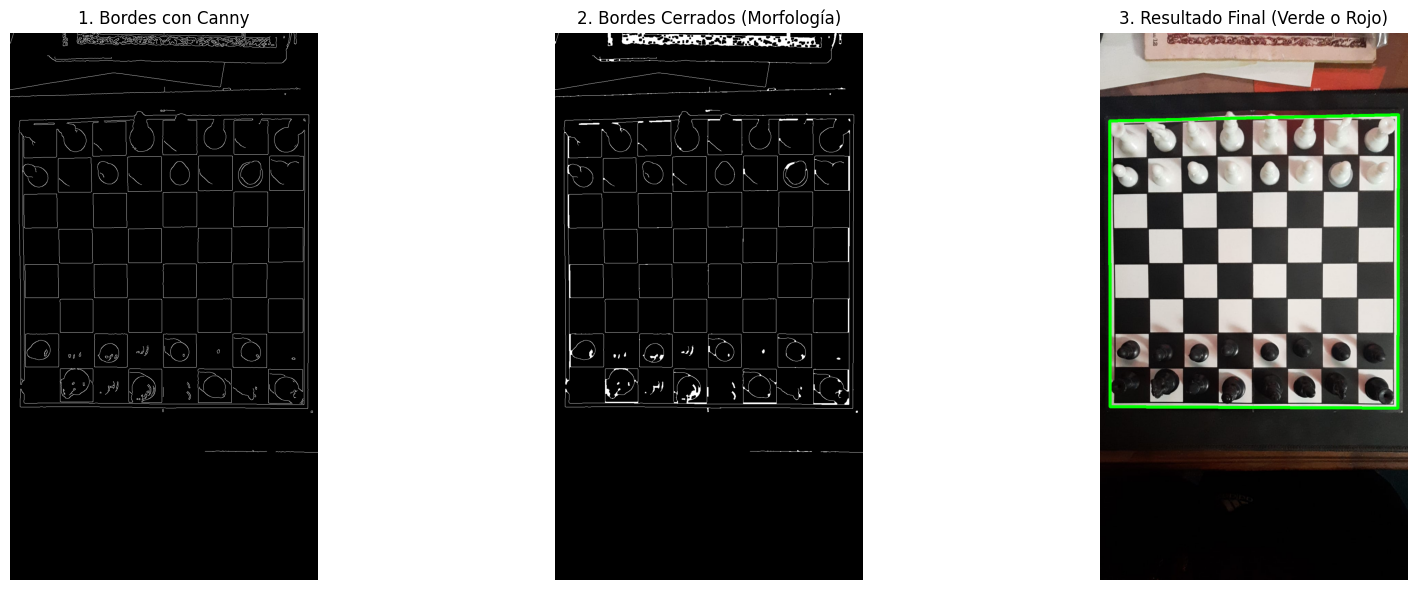

In [190]:
# 1. Cargar la imagen
ruta = "../../../data/raw/tablero_vertical_real.jpg"
imagen_gris = cv2.imread(ruta, 0)
imagen_color = cv2.imread(ruta)
imagen_color = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)

if imagen_gris is None:
    print("No se pudo cargar la imagen. Revisa la ruta.")
else:
    # 2. SUAVIZADO: Eliminamos imperfecciones o texturas sutiles
    desenfocado = cv2.GaussianBlur(imagen_gris, (5, 5), 0)
    
    # 3. CANNY (REALCE DE BORDES): Busca cambios bruscos de intensidad.
    # Los valores 50 y 150 son los umbrales de sensibilidad.
    mediana = np.median(desenfocado)
    umbral_bajo = int(max(0, (1.0 - 0.33) * mediana))
    umbral_alto = int(min(255, (1.0 + 0.33) * mediana))
    bordes_canny = cv2.Canny(desenfocado, 50, 150)
    
    # 4. OPERACIÓN MORFOLÓGICA (CIERRE): Creamos un "bloque" de 5x5 píxeles
    # para conectar líneas del borde exterior que hayan quedado separadas o rotas.
    kernel = np.ones((5, 5), np.uint8)
    bordes_cerrados = cv2.morphologyEx(bordes_canny, cv2.MORPH_CLOSE, kernel)

    # 5. ENCONTRAR CONTORNOS
    contornos, _ = cv2.findContours(bordes_cerrados, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
    
    tablero_esquinas = None
    
    if len(contornos) > 0:
        c_mas_grande = contornos[0]
        
        # calcular la envoltura convexa (la "banda elástica")
        hull = cv2.convexHull(c_mas_grande)
        
        # 6. FILTRAR POR RECTÁNGULO 
        perimetro = cv2.arcLength(hull, True)
        # Aumentamos un poco la tolerancia a 0.04 para ser menos estrictos
        aproximacion = cv2.approxPolyDP(hull, 0.04 * perimetro, True)
        
        if len(aproximacion) == 4:
            tablero_esquinas = aproximacion

    # 7. DIBUJAR Y MOSTRAR TODO EL PROCESO
    if tablero_esquinas is not None:
        print("¡Éxito! Se detectó el recuadro exterior del tablero.")
        cv2.drawContours(imagen_color, [tablero_esquinas], -1, (0, 255, 0), 7)
    else:
        print("No se encontró un contorno exterior de 4 esquinas perfecto.")
        if len(contornos) > 0:
            # Dibujamos el contorno original en rojo para depurar
            cv2.drawContours(imagen_color, [contornos[0]], -1, (255, 0, 0), 5)
            # Dibujamos el hull en amarillo para que veas la diferencia
            cv2.drawContours(imagen_color, [cv2.convexHull(contornos[0])], -1, (0, 255, 255), 3)

    # Bloque de visualización en Jupyter para diagnóstico
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(bordes_canny, cmap='gray')
    axs[0].set_title("1. Bordes con Canny")
    axs[0].axis('off')
    
    axs[1].imshow(bordes_cerrados, cmap='gray')
    axs[1].set_title("2. Bordes Cerrados (Morfología)")
    axs[1].axis('off')
    
    axs[2].imshow(imagen_color)
    axs[2].set_title("3. Resultado Final (Verde o Rojo)")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()


In [191]:
print(tablero_esquinas)

[[[  28  259]]

 [[ 871  241]]

 [[ 869 1097]]

 [[  29 1093]]]


Una vez delimitado el tablero podemos identificar las zonas en una matriz!!!

Aunque el tablero puede estar horizontal o vertical y las negras pueden estar arriba o abajo, para eso vamos a detectar

### Identificar negras y blancas

ya tenemos el ancho

Voy a identificar las posiciones del tablero de las imagenes para saber como se van actualizando las posiciones.

sacamos los minimos de de cada axis.

Límites calculados:
X mín (Izquierda): 28 | X máx (Derecha): 871
Y mín (Superior): 241  | Y máx (Inferior): 1097


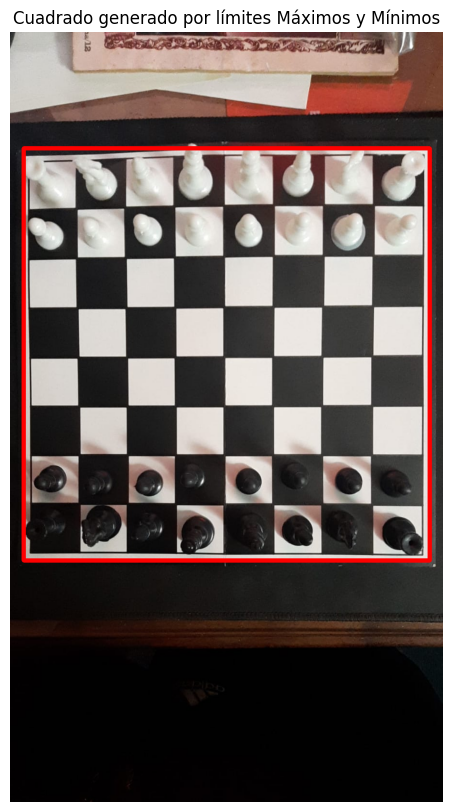

In [192]:

imagen_color = cv2.imread(ruta)
imagen_color = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)

if imagen_color is None:
    print("No se pudo cargar la imagen. Revisa la ruta.")
else:
    # 2. TUS PUNTOS ACTUALES
    #tablero_esquinas = np.array([[[295, 78]], [[249, 1046]], [[1277, 1036]], [[1258, 64]]])

    # Reshape para trabajar cómodamente con un array de (4, 2)
    puntos = tablero_esquinas.reshape(4, 2)

    # 3. EXTRAER MÍNIMOS Y MÁXIMOS DE CADA EJE
    # puntos[:, 0] hace referencia a todas las X
    # puntos[:, 1] hace referencia a todas las Y
    x_min = int(np.min(puntos[:, 0]))
    x_max = int(np.max(puntos[:, 0]))
    y_min = int(np.min(puntos[:, 1]))
    y_max = int(np.max(puntos[:, 1]))

    print(f"Límites calculados:")
    print(f"X mín (Izquierda): {x_min} | X máx (Derecha): {x_max}")
    print(f"Y mín (Superior): {y_min}  | Y máx (Inferior): {y_max}")

    # 4. DIBUJAR EL RECTÁNGULO EN LA IMAGEN
    # cv2.rectangle necesita la esquina superior izquierda (x_min, y_min) 
    # y la esquina inferior derecha (x_max, y_max)
    cv2.rectangle(imagen_color, (x_min, y_min), (x_max, y_max), (255, 0, 0), 7) # Rectángulo Azul, grosor 7

    # 5. MOSTRAR LA IMAGEN CON EL RECTÁNGULO
    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_color)
    plt.title("Cuadrado generado por límites Máximos y Mínimos")
    plt.axis('off')
    plt.show()

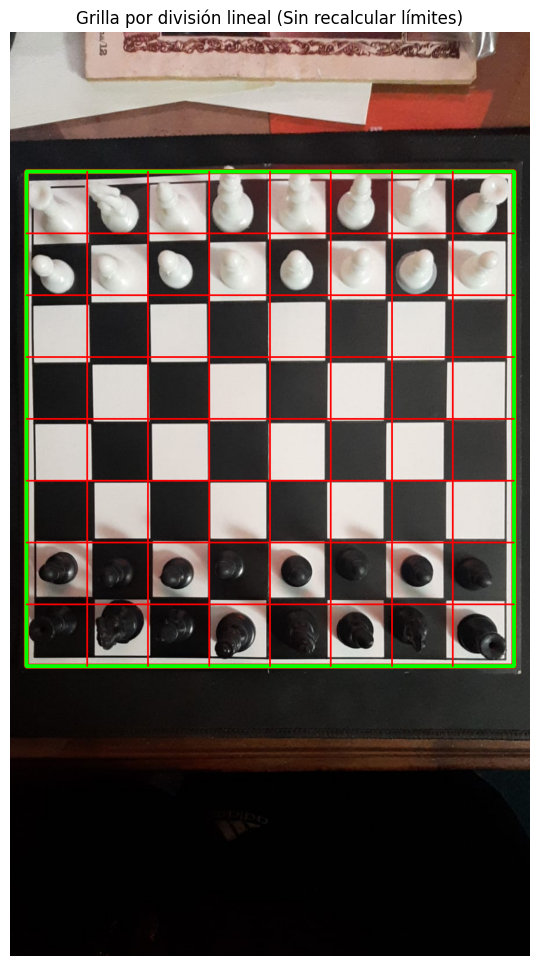

In [193]:
# 1. Calcular el tamaño de cada celda con las variables que ya tienes
ancho_total = x_max - x_min
alto_total = y_max - y_min

celda_ancho = ancho_total / 8
celda_alto = alto_total / 8

# 2. Dibujar el rectángulo contenedor exterior (Verde)
cv2.rectangle(imagen_color, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)

# 3. Dibujar las líneas de la grilla usando los límites existentes (Azul)
for i in range(1, 8):
    # Líneas Verticales
    x_linea = int(x_min + (i * celda_ancho))
    cv2.line(imagen_color, (x_linea, y_min), (x_linea, y_max), (255, 0, 0), 2)

    # Líneas Horizontales
    y_linea = int(y_min + (i * celda_alto))
    cv2.line(imagen_color, (x_min, y_linea), (x_max, y_linea), (255, 0, 0), 2)

# 4. Mostrar el resultado en Jupyter
plt.figure(figsize=(12, 12))
plt.imshow(imagen_color)
plt.title("Grilla por división lineal (Sin recalcular límites)")
plt.axis('off')
plt.show()

### Corregir la perspectiva

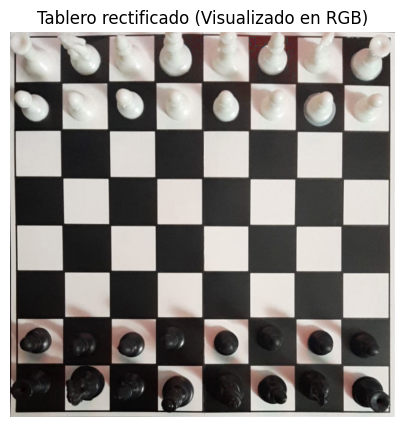

In [194]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ordenar_puntos(puntos):
    puntos = puntos.reshape((4, 2))
    puntos_ordenados = np.zeros((4, 2), dtype=np.float32)

    suma = puntos.sum(axis=1)
    puntos_ordenados[0] = puntos[np.argmin(suma)] # Arriba-Izquierda
    puntos_ordenados[2] = puntos[np.argmax(suma)] # Abajo-Derecha

    diff = np.diff(puntos, axis=1)
    puntos_ordenados[3] = puntos[np.argmin(diff)] # Arriba-Derecha
    puntos_ordenados[1] = puntos[np.argmax(diff)] # Abajo-Izquierda
    
    return puntos_ordenados


# Cargar imagen (OpenCV la carga en BGR por defecto)
imagen_bgr = cv2.imread(ruta)

# Convertir de BGR a HSV para trabajar en este espacio de color
imagen_hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV)

# Esquinas detectadas del tablero
# Deben estar en orden:
# superior izquierda, inferior izquierda,
# inferior derecha, superior derecha
pts_origen = ordenar_puntos(tablero_esquinas)

# Tamaño deseado para el tablero corregido
lado = 800

pts_destino = np.array([
    [0, 0],
    [0, lado],
    [lado, lado],
    [lado, 0]
], dtype=np.float32)

# Matriz de homografía
H = cv2.getPerspectiveTransform(pts_origen, pts_destino)

# Corregir perspectiva trabajando directamente sobre la imagen HSV
tablero_rectificado_hsv = cv2.warpPerspective(
    imagen_hsv,
    H,
    (lado, lado)
)

# --- NOTA PARA VISUALIZACIÓN ---
# Como plt.imshow necesita RGB para mostrar los colores correctamente,
# convertimos el resultado rectificado de HSV a RGB solo para el gráfico.
tablero_rectificado_rgb = cv2.cvtColor(tablero_rectificado_hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(5,5))
plt.imshow(tablero_rectificado_rgb)
plt.title("Tablero rectificado (Visualizado en RGB)")
plt.axis("off")
plt.show()

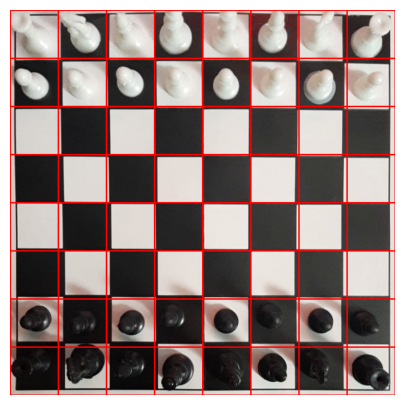

In [195]:
img = tablero_rectificado_hsv.copy()

lado = img.shape[0]
tam_celda = lado / 8

for fila in range(8):
    for columna in range(8):

        x1 = int(columna * tam_celda)
        y1 = int(fila * tam_celda)

        x2 = int((columna + 1) * tam_celda)
        y2 = int((fila + 1) * tam_celda)

        # En HSV, (0, 255, 255) representa un Rojo Puro y Brillante
        # H=0 (Rojo), S=255 (Máxima saturación), V=255 (Máximo brillo)
        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (0, 255, 255), 
            2
        )
        

# CORRECCIÓN AQUÍ: Convertimos la imagen con los rectángulos ya dibujados a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb) # Ahora le pasamos la imagen correctamente convertida
plt.axis("off")
plt.show()

Una vez obtenida la imagen, vamos a analizar donde se encuentran las negras y las blancas

In [196]:
matriz = np.zeros(shape=(8,8))
print(matriz)

x_inf = np.min(tablero_esquinas[:])

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


### Clases Cell y Board

Encapsulamos la lógica de detección en clases: `Cell` guarda las coordenadas de cada casilla, y `Board` construye las 64 celdas a partir de la imagen rectificada y expone la matriz 8x8 (por ahora con ceros, sin piezas).

In [ ]:
import numpy as np

class Cell():

    def __init__(self, x_left, x_right, y_up, y_down, row=None, col=None):
        self.x_left = x_left
        self.x_right = x_right
        self.y_up = y_up
        self.y_down = y_down
        self.row = row
        self.col = col
        self.value = 0  # pieza (vacío por ahora)

    def __repr__(self):
        return (f"Cell[{self.row},{self.col}] "
                f"x=({self.x_left},{self.x_right}) y=({self.y_up},{self.y_down}) "
                f"value={self.value}")


class Board():

    def __init__(self, imagen_rectificada):
        self.imagen = imagen_rectificada #imagen hsv
        lado = imagen_rectificada.shape[0]
        self.tam_celda = lado / 8
        self.celdas = self._construir_celdas()
        self.matriz = np.zeros((8, 8), dtype=int)

    def _construir_celdas(self):
        celdas = []
        for fila in range(8):
            fila_celdas = []
            for col in range(8):
                x1 = int(col * self.tam_celda)
                y1 = int(fila * self.tam_celda)
                x2 = int((col + 1) * self.tam_celda)
                y2 = int((fila + 1) * self.tam_celda)
                celda = Cell(x1, x2, y1, y2, row=fila, col=col)
                fila_celdas.append(celda)
            celdas.append(fila_celdas)
        return celdas

    def dibujar(self, img=None):
        import cv2
        if img is None:
            img = self.imagen.copy()
        for fila in self.celdas:
            for celda in fila:
                cv2.rectangle(
                    img,
                    (celda.x_left, celda.y_up),
                    (celda.x_right, celda.y_down),
                    (255, 0, 0),
                    2
                )
        return cv2.cvtColor(img, cv2.COLOR_HSV2RGB)


Matriz del tablero:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]

Celda [0][0]: x_left=0, x_right=100, y_up=0, y_down=100, value=0


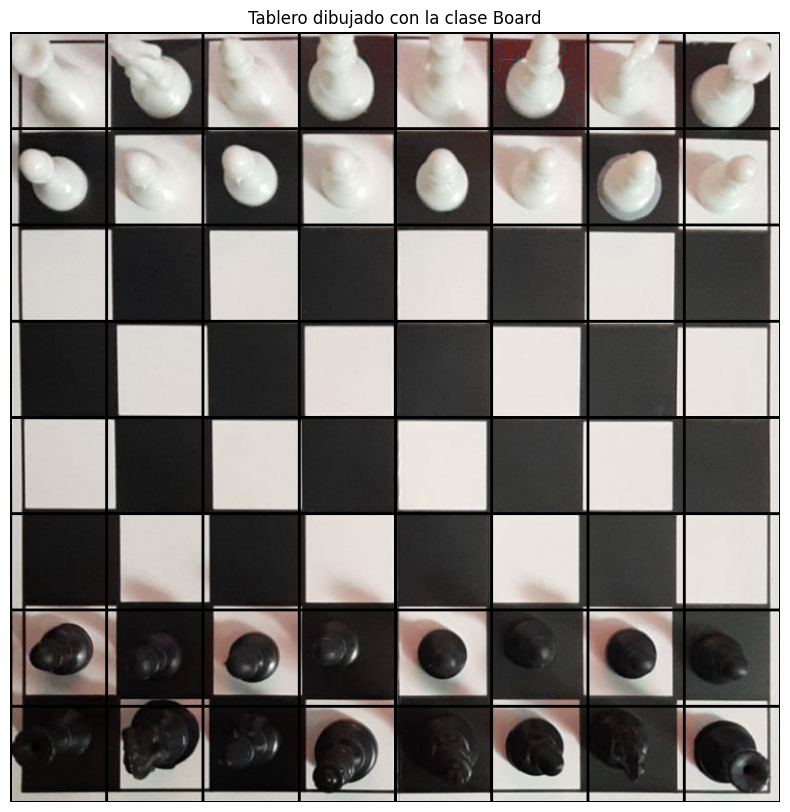

In [198]:
# Crear el tablero a partir de la imagen rectificada
tablero = Board(tablero_rectificado_hsv)

# Mostrar la matriz (8x8 de ceros, sin piezas todavía)
print("Matriz del tablero:")
print(tablero.matriz)

# Verificar una celda de ejemplo: fila 0, columna 0 (esquina superior izquierda)
celda_ejemplo = tablero.celdas[0][0]
print(f"\nCelda [0][0]: x_left={celda_ejemplo.x_left}, x_right={celda_ejemplo.x_right}, "
      f"y_up={celda_ejemplo.y_up}, y_down={celda_ejemplo.y_down}, value={celda_ejemplo.value}")



# Dibujar el tablero usando la clase
img_board = tablero.dibujar()

plt.figure(figsize=(10, 10))
plt.imshow(img_board)
plt.title("Tablero dibujado con la clase Board")
plt.axis("off")
plt.show()

In [199]:
print(celda_ejemplo)

Cell[0,0] x=(0,100) y=(0,100) value=0


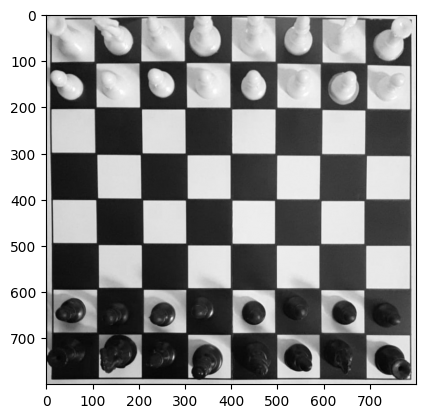

In [200]:
plt.imshow(tablero.imagen[:,:,2], cmap = "gray")
plt.show()

Vamos a analizar el perfil de grises de las esquinas para identificar dond stan las blancas y las ngras, considrando qu pueden star vereticals u horizontals

In [201]:
import numpy as np

img_g = tablero.imagen[:, :, 2]

x_mid_init = int((tablero.celdas[0][0].x_left + tablero.celdas[0][0].x_right) / 2)
y_mid_init = int((tablero.celdas[0][0].y_up + tablero.celdas[0][0].y_down) / 2)

signals = {
    "col": img_g[:, x_mid_init],
    "row": img_g[y_mid_init, :]
}

diferencias = {}
medias_por_signal = {}

for nombre, signal in signals.items():

    n = len(signal)
    q = n // 4

    primer_cuarto = signal[:q]
    ultimo_cuarto = signal[-q:]

    media_inicio = np.mean(primer_cuarto)
    media_fin = np.mean(ultimo_cuarto)

    medias_por_signal[nombre] = [media_inicio, media_fin]
    diferencias[nombre] = abs(media_inicio - media_fin)

# Señal ganadora
sentido = max(diferencias, key=diferencias.get)

# Medias de la señal ganadora
medias_ganadora = medias_por_signal[sentido]

print(f"Sentido ganador: {sentido}")
print(f"Medias [primer cuarto, último cuarto]: {medias_ganadora}")

# Si querés usarlo luego:
# sentido -> "row" o "col"
# medias_ganadora -> [media_primer_cuarto, media_ultimo_cuarto]

Sentido ganador: col
Medias [primer cuarto, último cuarto]: [np.float64(163.415), np.float64(48.435)]


### Transformada de Hough

In [202]:
def deteccion_lineas(image):
    # binarizar
    blur = cv2.GaussianBlur(image, (9, 9), 0)
    bin_img = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # canny
    v = np.median(bin_img)
    sigma = 0.33
    superior = int(max(0, (1.0 - sigma) * v))
    inferior = int(min(255, (1.0 + sigma) * v))
    canny = cv2.Canny(bin_img, superior, inferior, apertureSize = 3)
    
    # hough
    lines = cv2.HoughLines(image=canny,rho=1.0,theta=np.pi/180, threshold=200,lines=np.array([]))
    
    # agrupar similares y quedarnos con la media
    lineas_unificadas = unificar_lineas(lines)
    lineas_unificadas = unificar_lineas(lineas_unificadas)

    return lineas_unificadas

def unificar_lineas(lineas, umbral_rho=30, umbral_theta=np.pi/180*15):
    lineas_agrupadas = []

    # Para cada línea, si el ángulo o la distancia coinciden dentro del umbral con otra línea,
    # se agrupan en una misma lista.
    for linea in lineas:
        for rho, theta in linea:
            grupo_coincidente = None
            for grupo in lineas_agrupadas:
                for u_rho, u_theta in grupo:
                    if (abs(u_rho - rho) < umbral_rho and abs(u_theta - theta) < umbral_theta) or \
                       (abs(u_rho + rho) < umbral_rho and abs(u_theta - (theta + np.pi)) % (2 * np.pi) < umbral_theta):
                        grupo_coincidente = grupo
                        break
                if grupo_coincidente:
                    break
            if grupo_coincidente:
                grupo_coincidente.append((rho, theta))
            else:
                lineas_agrupadas.append([(rho, theta)])

    # Para cada grupo de líneas, calculamos la línea mediana
    lineas_unificadas = []
    for grupo in lineas_agrupadas:
        mediana_rho, mediana_theta = obtener_mediana_rho_theta(grupo)
        lineas_unificadas.append((mediana_rho, mediana_theta))

    return np.array([[linea] for linea in lineas_unificadas], dtype=np.float32)


def obtener_mediana_rho_theta(grupo):
    grupo.sort(key=lambda a: a[1])
    indice = (len(grupo) - 1) // 2
    return grupo[indice]

def segmentar_lineas_por_angulo(lineas, umbral_theta=np.pi/180*10):
    lineas_agrupadas = []

    # Paso 1: Agrupar líneas por ángulo
    for linea in lineas:
        for rho, theta in linea:
            grupo_coincidente = None
            for grupo in lineas_agrupadas:
                for u_rho, u_theta in grupo:
                    if ((abs(u_theta - theta) < umbral_theta) or \
                        abs(u_theta - (theta + np.pi)) % (2 * np.pi) < umbral_theta or \
                        abs(u_theta - (np.pi - theta)) < umbral_theta or \
                        abs(theta - (np.pi - u_theta)) < umbral_theta):
                        grupo_coincidente = grupo
                        break
                if grupo_coincidente:
                    break
            if grupo_coincidente:
                grupo_coincidente.append((rho, theta))
            else:
                lineas_agrupadas.append([(rho, theta)])
    
    # Paso 2: Encontrar los 2 grupos de ángulos más comunes
    lineas_agrupadas = sorted(lineas_agrupadas, key=len, reverse=True)
    
    if len(lineas_agrupadas) < 2:
        print("Error")
        raise Exception("Se detectaron menos de 2 líneas")
    
    # Obtener los dos ángulos más comunes (suele haber ~90° de diferencia entre ellos)
    lineas_vert = np.array([[linea] for linea in lineas_agrupadas[0]], dtype=np.float32)
    lineas_horiz = np.array([[linea] for linea in lineas_agrupadas[1]], dtype=np.float32)
    
    return (lineas_vert, lineas_horiz)


def aplicar_lineas_horiz_vert(imagen, lineas_horiz, lineas_vert):
    nueva_imagen = cv2.cvtColor(imagen.copy(), cv2.COLOR_GRAY2BGR)
    
    # Trazar líneas horizontales en color Verde
    for linea in lineas_horiz:
        for rho, theta in linea:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 2000 * (-b))
            y1 = int(y0 + 2000 * (a))
            x2 = int(x0 - 2000 * (-b))
            y2 = int(y0 - 2000 * (a))
            cv2.line(nueva_imagen, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Trazar líneas verticales en color Rojo
    for linea in lineas_vert:
        for rho, theta in linea:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 2000 * (-b))
            y1 = int(y0 + 2000 * (a))
            x2 = int(x0 - 2000 * (-b))
            y2 = int(y0 - 2000 * (a))
            cv2.line(nueva_imagen, (x1, y1), (x2, y2), (0, 0, 255), 2)
            
    return nueva_imagen

def plotImage(image):
    #We need to convert from BRG to RGB (just so we can display)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    title = "Image "
    plt.title(title)
    plt.show()

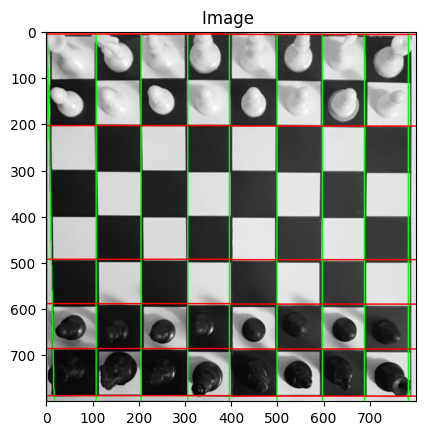

In [203]:
ruta = "../../../data/raw/tablero_fuga_poco.jpg"
imagen_gris = cv2.imread(ruta, 0)
tablero_rectificado_gray = cv2.cvtColor(tablero_rectificado_rgb, cv2.COLOR_RGB2GRAY)

imagen_analizar = tablero_rectificado_gray

lineas_unificadas = deteccion_lineas(imagen_analizar)
lineA, lineB = segmentar_lineas_por_angulo(lineas_unificadas, umbral_theta=np.pi/180*10)

hozVertImage = aplicar_lineas_horiz_vert(imagen_analizar, lineA, lineB)
plotImage(hozVertImage)

In [204]:
def interseccion(linea1, linea2):
    """Calcula el punto (x, y) donde se cruzan dos líneas polares."""
    rho1, theta1 = linea1[0]
    rho2, theta2 = linea2[0]
    
    # Sistema de ecuaciones: A * [x, y]^T = b
    A = np.array([
        [np.cos(theta1), np.sin(theta1)],
        [np.cos(theta2), np.sin(theta2)]
    ])
    b = np.array([rho1, rho2])
    
    try:
        x, y = np.linalg.solve(A, b)
        return (int(np.round(x)), int(np.round(y)))
    except np.linalg.LinAlgError:
        return None

def obtener_esquinas_tablero(lineas_vert, lineas_horiz):
    """Obtiene los 4 puntos extremos del tablero."""
    # Ordenamos las líneas por su distancia al origen (rho)
    # Usamos abs() por si Hough devolvió algún rho negativo con ángulos > 90
    vert_ordenadas = sorted(lineas_vert, key=lambda l: abs(l[0][0]))
    horiz_ordenadas = sorted(lineas_horiz, key=lambda l: abs(l[0][0]))
    
    izq = vert_ordenadas[0]
    der = vert_ordenadas[-1]
    sup = horiz_ordenadas[0]
    inf = horiz_ordenadas[-1]
    
    esquina_sup_izq = interseccion(izq, sup)
    esquina_sup_der = interseccion(der, sup)
    esquina_inf_izq = interseccion(izq, inf)
    esquina_inf_der = interseccion(der, inf)
    
    return [esquina_sup_izq, esquina_inf_izq, esquina_inf_der, esquina_sup_der]

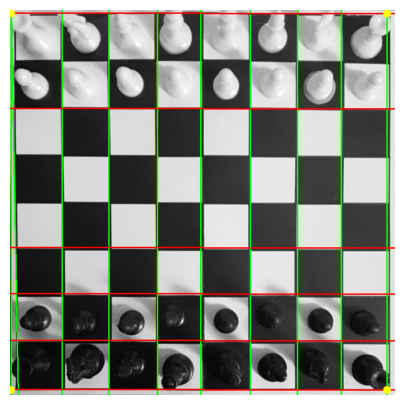

In [205]:
esquinas = obtener_esquinas_tablero(lineA, lineB) 

imagen_esquinas = hozVertImage.copy() 

for punto in esquinas:
    if punto is not None:
        cv2.circle(imagen_esquinas, punto, radius=8, color=(0, 255, 255), thickness=-1)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(imagen_esquinas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [206]:
pts_origen = np.array(esquinas, dtype=np.float32)
lado = 800

pts_destino = np.array([
            [0,    0   ],   # superior izquierda
            [0,    lado],   # inferior izquierda
            [lado, lado],   # inferior derecha
            [lado, 0   ],   # superior derecha
        ], dtype=np.float32)

H = cv2.getPerspectiveTransform(pts_origen, pts_destino)
imagen_final = cv2.warpPerspective(imagen_analizar, H, (lado, lado))

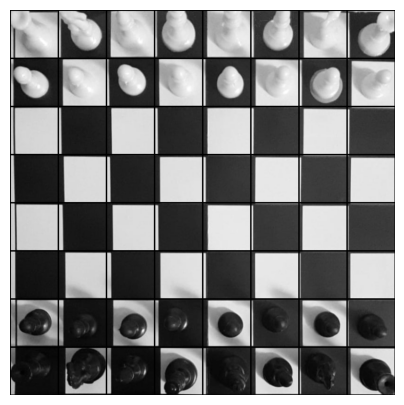

In [207]:
img = imagen_final.copy()

lado = img.shape[0]
tam_celda = lado / 8

for fila in range(8):
    for columna in range(8):

        x1 = int(columna * tam_celda)
        y1 = int(fila * tam_celda)

        x2 = int((columna + 1) * tam_celda)
        y2 = int((fila + 1) * tam_celda)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)
        
img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()